# Paper A · Experiment 1 — Landmark-importance ranking and precision budget

**Claim under test.** The correction angle's sensitivity to landmark displacement is
*strongly non-uniform*: a few landmarks dominate, and the osteotomy hinge — the vertex
where the angle is read — is nearly irrelevant to its value.

**Method.** The Miniaci/Fujisawa construction $g$ (`hto.geometry.evaluate_side_geometry`)
is reimplemented in `torch` so that

$$\delta m \;\approx\; \sum_i J_i \cdot \delta p_i, \qquad
  J_i = \frac{\partial g}{\partial p_i} \in \mathbb{R}^2$$

is available by automatic differentiation on the real three-observer-mean annotations.
No new modelling cost — $g$ is the construction the baseline already uses, unchanged.

**Outputs**

| # | Output | Feeds |
|---|--------|-------|
| 1 | Per-hemisphere Jacobian $J$ (the *sensitivity object*) | Papers B & D |
| 2 | Cohort importance ranking $\lVert J_i\rVert$ with spread + ratios | headline figure |
| 3 | Precision budget $\lVert\delta p_i\rVert \lesssim \tau/(z\sqrt{k}\lVert J_i\rVert)$ | §3.2 |
| 4 | Risk $=$ importance $\times$ localisability, from **out-of-fold** U-Net error | risk budget |
| 5 | Delta-method calibration (predicted vs actual $\delta m$) | E2 / E3 seed |

**Provenance.** Same annotations, same seeded 5-fold split, same checkpoints, and the same
geometry as `hto_unet_baseline.ipynb`. Hemispheres are pooled out-of-fold, so §7 is
comparable to the baseline's $n=107$ cross-validated correction-angle table.

## 0 · Configuration

Mirrors cell 0 of `hto_unet_baseline.ipynb`. Do not drift from it — the seed and the
canvas size determine which hemispheres land in which fold.

In [1]:
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader

from hto.data import GlobalRadiographKeypointDataset
from hto.geometry import evaluate_side_geometry, map_global_to_orig
from hto.metrics import extract_coordinates
from hto.model import UNetKeypointHalfHeatmap
from hto.sensitivity import (
    HEMISPHERE_BASES,
    LANDMARK_LABELS,
    SIDE_KEYS,
    angle_and_jacobian,
    miniaci_angle_signed,
    points_to_tensor,
    precision_budget,
    validate,
)

# ── identical to the baseline notebook ──────────────────────────────────
DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED           = 42
TARGET_SIZE    = 768
HEATMAP_SCALE  = 0.5
SIGMA          = 6.0
BATCH_SIZE     = 4
N_SPLITS       = 5

UNET_BASE_CH   = 64
UNET_BILINEAR  = False
CHECKPOINT_DIR = "kfolds_models"

# ── E1-specific ─────────────────────────────────────────────────────────
GT_ONLY   = False      # True -> skip inference entirely (§4-5 only, no GPU, no checkpoints)
USE_CACHE = True       # reuse results/E1/E1_cohort.npz instead of re-running inference
OUT_DIR   = Path("results/E1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOLERANCE_DEG    = 1.63     # clinical correction-angle tolerance (Jiang et al. 2022)
Z_BUDGET         = 1.0      # 1.0 reproduces tau/(sqrt(k)||J_i||); 1.96 for a 95% budget
PIXEL_SPACING_MM = None     # mm per pixel, if known; None -> pixels only

# ── landmark ordering and labels come from the package ──────────────────
# hto.sensitivity.SIDE_KEYS is the per-hemisphere channel order, identical to _SIDE_KEYS
# in the baseline notebook; §3 asserts it against GLOBAL_KEYPOINT_NAMES.
HEMISPHERES = HEMISPHERE_BASES                 # [(0, "left"), (6, "right")]
PRETTY = LANDMARK_LABELS
K = len(SIDE_KEYS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device {device}")
print(f"annotations: {COCO_JSON_PATH}  (exists: {os.path.exists(COCO_JSON_PATH)})")
print(f"canvas {TARGET_SIZE}px | heatmap scale {HEATMAP_SCALE} | tau {TOLERANCE_DEG} deg | k={K}")

torch 2.5.1+cu121 | device cuda
annotations: /tf/data/hto/xrays/hto_annotations.json  (exists: True)
canvas 768px | heatmap scale 0.5 | tau 1.63 deg | k=6


## 1 · Differentiable $g$ — `hto.sensitivity`

The differentiable geometry lives in the package, not in this notebook, so the analysis
and its validation cannot drift apart:

| Symbol | Role |
|--------|------|
| `hto.geometry.evaluate_side_geometry` | the NumPy **reference** — unchanged |
| `hto.sensitivity.miniaci_angle_signed` | torch transcription of the same construction |
| `hto.sensitivity.angle_and_jacobian` | $(\alpha,\ J)$ for one hemisphere |
| `hto.sensitivity.validate` | the checks run in §3 |

`miniaci_angle_signed` returns the **signed** angle. `abs()` recovers the repo's unsigned
value exactly, but differentiating the signed quantity avoids the kink that
`abs` / `min(raw, 2*pi - raw)` introduces at $\alpha = 0$. Since
$\partial|\alpha|/\partial p = \operatorname{sign}(\alpha)\,\partial\alpha/\partial p$,
the magnitudes $\lVert J_i\rVert$ are unchanged — numerical hygiene, not a different
quantity. §3 asserts the equivalence on the real cohort.

In [2]:
print("landmark order (per hemisphere, channel base 0 = left, 6 = right):")
for i, n in enumerate(SIDE_KEYS):
    print(f"  slot {i}  ch {i:>2d} / {i + 6:<2d}  {n:12s} {PRETTY[n]}")

landmark order (per hemisphere, channel base 0 = left, 6 = right):
  slot 0  ch  0 / 6   femur_head   Femoral head centre
  slot 1  ch  1 / 7   knee_inner   Medial tibial plateau
  slot 2  ch  2 / 8   ost_point    Osteotomy hinge
  slot 3  ch  3 / 9   knee_outer   Lateral tibial plateau
  slot 4  ch  4 / 10  ankle_inner  Medial malleolus
  slot 5  ch  5 / 11  ankle_outer  Lateral malleolus


## 2 · Cohort — ground truth and out-of-fold predictions

One pass reproducing the baseline's evaluation path exactly:

* rebuild the dataset with `split="all"` and the same seed;
* replay `KFold(n_splits=5, shuffle=True, random_state=SEED)`;
* for each fold, load `best_model_fold{k}.pt` and run it on **that fold's held-out
  images only** — so every prediction is genuinely out-of-fold;
* decode heatmap peaks, invert the letterbox with `map_global_to_orig`, and split each
  radiograph into its two hemispheres at channel bases 0 (left) and 6 (right).

A hemisphere is kept only when all six landmarks are annotated — the same completeness
rule as `evaluate_fold_angles`, which is what makes $n = 107$ rather than 108.

With `GT_ONLY = True` the annotations are read straight out of `ds.samples` (already in
original-image coordinates), skipping image loading and inference altogether.

In [3]:
def _hemispheres_from_coords(gt_c, pred_c, orig_shape, case_id, to_orig):
    # Split one radiograph's 12 channels into hemispheres, keeping only complete ones.
    out = []
    for base, side in HEMISPHERES:
        pts_gt, pts_pred, complete = {}, {}, True
        for off, name in enumerate(SIDE_KEYS):
            slot = base + off
            if gt_c[slot][0] < 0:
                complete = False
                break
            pts_gt[name] = to_orig(gt_c[slot], orig_shape)
            if pred_c is not None:
                pts_pred[name] = to_orig(pred_c[slot], orig_shape)
        if complete:
            out.append({"case_id": case_id, "side": side, "points": pts_gt,
                        "pred": pts_pred if pred_c is not None else None,
                        "pixel_spacing_mm": PIXEL_SPACING_MM})
    return out


def build_cohort_gt_only(ds):
    # Annotations only: ds.samples keypoints are already in original-image coordinates.
    recs = []
    for s in ds.samples:
        k = s["keypoints"]
        coords = np.array([[k[i * 3], k[i * 3 + 1]] for i in range(12)], dtype=float)
        vis    = np.array([k[i * 3 + 2] for i in range(12)])
        coords[vis <= 0] = -1.0
        recs += _hemispheres_from_coords(coords, None, s["orig_size"],
                                         Path(s["img_path"]).stem, lambda c, _o: np.asarray(c))
    return recs


def build_cohort_oof(ds):
    # Ground truth + out-of-fold predictions, replaying the baseline's fold assignment.
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    recs = []
    for fold, (_train_idx, val_idx) in enumerate(kf.split(np.arange(len(ds))), start=1):
        ckpt = Path(CHECKPOINT_DIR) / f"best_model_fold{fold}.pt"
        if not ckpt.exists():
            raise FileNotFoundError(f"{ckpt} missing — run the baseline's k-fold cell first")

        model = UNetKeypointHalfHeatmap(num_keypoints=12, base_ch=UNET_BASE_CH,
                                        bilinear=UNET_BILINEAR).to(device).eval()
        model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))

        fold_ds = GlobalRadiographKeypointDataset(
            COCO_JSON_PATH, split="val", target_size=TARGET_SIZE,
            heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED, indices=val_idx)
        loader = DataLoader(fold_ds, batch_size=BATCH_SIZE, shuffle=False)

        n_before = len(recs)
        with torch.no_grad():
            for batch in loader:
                pred_hms = model(batch["image"].to(device))
                coords = extract_coordinates(pred_hms.cpu(),
                                             scale_factor=1.0 / HEATMAP_SCALE).numpy()
                gts        = batch["keypoint"].numpy()
                orig_sizes = batch["orig_size"].numpy()
                for b, path in enumerate(batch["img_path"]):
                    recs += _hemispheres_from_coords(
                        gts[b], coords[b], orig_sizes[b], Path(path).stem,
                        lambda c, o: map_global_to_orig(c, o, TARGET_SIZE))
        print(f"  fold {fold}: {len(val_idx)} radiographs -> {len(recs) - n_before} hemispheres")
    return recs


CACHE = OUT_DIR / "E1_cohort.npz"
full_ds = GlobalRadiographKeypointDataset(
    COCO_JSON_PATH, split="all", target_size=TARGET_SIZE,
    heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
print(f"dataset: {len(full_ds)} radiographs")

if GT_ONLY:
    hemispheres = build_cohort_gt_only(full_ds)
    pred_note = "none (GT_ONLY)"
elif USE_CACHE and CACHE.exists():
    z = np.load(CACHE, allow_pickle=True)
    hemispheres = list(z["records"])
    pred_note = f"cached out-of-fold predictions ({CACHE.name})"
    print(f"loaded cache: {CACHE}")
else:
    print(f"running {N_SPLITS}-fold out-of-fold inference on {device}...")
    hemispheres = build_cohort_oof(full_ds)
    np.savez_compressed(CACHE, records=np.array(hemispheres, dtype=object))
    pred_note = f"out-of-fold U-Net, best_model_fold[1-{N_SPLITS}].pt"

alphas = np.array([evaluate_side_geometry(h["points"])[0] for h in hemispheres])
n_rad = len({h["case_id"] for h in hemispheres})

print(f"\n{len(hemispheres)} hemispheres from {n_rad} radiographs | predictions: {pred_note}")
print(f"correction angle: mean {alphas.mean():.2f} deg | median {np.median(alphas):.2f} "
      f"| range {alphas.min():.2f}-{alphas.max():.2f}")

dataset: 54 radiographs
running 5-fold out-of-fold inference on cuda...
  fold 1: 11 radiographs -> 22 hemispheres
  fold 2: 11 radiographs -> 21 hemispheres
  fold 3: 11 radiographs -> 22 hemispheres
  fold 4: 11 radiographs -> 22 hemispheres
  fold 5: 10 radiographs -> 20 hemispheres

107 hemispheres from 54 radiographs | predictions: out-of-fold U-Net, best_model_fold[1-5].pt
correction angle: mean 6.92 deg | median 6.44 | range 0.46-24.82


## 3 · Verification — gate the analysis before running it

`hto.sensitivity.validate` run on the **real** cohort. Every check is a hard assertion; if
any fails, nothing downstream is trustworthy.

1. **Parity** — torch $|\alpha|$ vs `evaluate_side_geometry`, on every hemisphere.
2. **Autodiff correctness** — $J$ vs central finite differences taken *on the NumPy
   reference*, so the derivative is validated against the code the baseline ships.
3. **Delta-method validity** — a 1.5 px perturbation reproduced by
   $\sum_i J_i\cdot\delta p_i$, bounding the linearisation error far inside $\tau$.
4. **Structural identity** — the malleoli enter $g$ only through their midpoint, so
   $J_{\text{ankle-inner}} = J_{\text{ankle-outer}}$ must hold exactly. A property of the
   construction rather than of the code, so it catches a mis-ordered `SIDE_KEYS`.
5. **Channel order** — `SIDE_KEYS` against `GLOBAL_KEYPOINT_NAMES` in the baseline notebook.

The same function runs standalone as `python -m hto.sensitivity.validation`.

In [4]:
checks = validate([h["points"] for h in hemispheres], fd_sample=len(hemispheres))

geometry validation | 107 supplied hemispheres
  alpha mean 6.92 deg, range 0.46-24.82

  [1] parity vs evaluate_side_geometry, n=107  3.55e-15 deg   OK
  [2] autodiff vs finite differences,   n=107  6.76e-09 rel   OK
  [3] delta-method @ 1.5 px jitter,     n=107  2.77e-04 deg   OK
  [4] malleoli symmetry,                n=107  0.00e+00 rel   OK
  [5] SIDE_KEYS vs GLOBAL_KEYPOINT_NAMES     OK


## 4 · Per-hemisphere Jacobians → the importance ranking

$\lVert J_i\rVert$ is in **degrees of correction-angle error per pixel** of displacement of
landmark $i$. Ratios are computed *within* each hemisphere and then summarised, rather than
as a ratio of cohort means — a ratio of means is biased when the denominator is small, which
is exactly the hinge's situation.

In [5]:
rows, J_all = [], np.zeros((len(hemispheres), K, 2))

for h_idx, h in enumerate(hemispheres):
    a_signed, a_unsigned, J = angle_and_jacobian(h["points"])
    J_all[h_idx] = J
    norms = np.linalg.norm(J, axis=1)
    for i, name in enumerate(SIDE_KEYS):
        rows.append({
            "case_id": h["case_id"], "side": h["side"], "hemisphere": h_idx,
            "landmark": name, "alpha_deg": a_unsigned, "alpha_signed_deg": a_signed,
            "Jx": J[i, 0], "Jy": J[i, 1], "J_norm": norms[i],
            "J_share": norms[i] / norms.sum(),
        })

jac = pd.DataFrame(rows)

kink = jac.loc[jac.alpha_deg < 0.5, "hemisphere"].nunique()
if kink:
    print(f"note: {kink} hemisphere(s) with alpha < 0.5 deg (near the |alpha| kink); "
          f"||J|| magnitudes remain valid, signed direction is unstable there.\n")

wide   = jac.pivot_table(index="hemisphere", columns="landmark", values="J_norm")
least  = wide.mean().idxmin()
ratios = wide.div(wide[least], axis=0)          # per-hemisphere ratio vs least influential

summary = pd.DataFrame({
    "mean":    wide.mean(),
    "sd":      wide.std(),
    "median":  wide.median(),
    "q05":     wide.quantile(0.05),
    "q95":     wide.quantile(0.95),
    "share_%": 100 * wide.div(wide.sum(axis=1), axis=0).mean(),
    f"x_vs_{least}_median": ratios.median(),
    f"x_vs_{least}_iqr":    ratios.quantile(0.75) - ratios.quantile(0.25),
}).reindex(SIDE_KEYS).sort_values("median", ascending=False)

keys = list(summary.index)                       # most -> least influential
summary.index = [PRETTY[n] for n in summary.index]
print("Landmark importance  ||J_i||  [deg per pixel]\n")
print(summary.round(5).to_string())
print(f"\nspread, median ||J||: {wide[keys[0]].median() / wide[keys[-1]].median():.1f}x "
      f"({PRETTY[keys[0]].lower()} vs {PRETTY[keys[-1]].lower()})")

note: 1 hemisphere(s) with alpha < 0.5 deg (near the |alpha| kink); ||J|| magnitudes remain valid, signed direction is unstable there.

Landmark importance  ||J_i||  [deg per pixel]

                           mean       sd   median      q05      q95   share_%  x_vs_ost_point_median  x_vs_ost_point_iqr
Lateral tibial plateau  0.02631  0.00198  0.02693  0.02310  0.02873  30.40557               10.00473            12.71837
Femoral head centre     0.01888  0.00140  0.01943  0.01670  0.02089  21.82477                7.12238             9.09425
Medial tibial plateau   0.01579  0.00119  0.01616  0.01386  0.01724  18.24334                6.00284             7.63102
Medial malleolus        0.01139  0.00090  0.01142  0.00989  0.01266  13.16375                4.36282             5.66750
Lateral malleolus       0.01139  0.00090  0.01142  0.00989  0.01266  13.16375                4.36282             5.66750
Osteotomy hinge         0.00282  0.00187  0.00254  0.00040  0.00603   3.19881              

## 5 · Precision budget

Treating the $k$ landmark errors as independent and isotropic with per-landmark scale
$\sigma_i$, $\;\delta m \sim \mathcal{N}\!\big(0,\ \sum_i \lVert J_i\rVert^2\sigma_i^2\big)$.
Allocating the budget equally and requiring $z\cdot\mathrm{sd}(\delta m)\le\tau$:

$$\sigma_i \;\le\; \frac{\tau}{z\sqrt{k}\,\lVert J_i\rVert}$$

`Z_BUDGET = 1.0` reproduces the form in §3.2; set `1.96` for a 95% budget. Reported at the
cohort **median** $\lVert J_i\rVert$ (typical case) and at the **95th percentile** (worst
case) — the latter is what a safety argument should quote.

In [6]:
_budget = lambda s: precision_budget(s.reindex(keys).values,
                                     tolerance_deg=TOLERANCE_DEG, z=Z_BUDGET, k=K)
budget = pd.DataFrame({
    "||J|| median": wide.median().reindex(keys),
    "||J|| q95":    wide.quantile(0.95).reindex(keys),
    "budget_px (typical)": _budget(wide.median()),
    "budget_px (worst)":   _budget(wide.quantile(0.95)),
}, index=keys)

spacings = [h["pixel_spacing_mm"] for h in hemispheres if h["pixel_spacing_mm"]]
if spacings:
    mm_per_px = float(np.mean(spacings))
    budget["||J|| median (deg/mm)"] = budget["||J|| median"] / mm_per_px
    budget["budget_mm (typical)"]   = budget["budget_px (typical)"] * mm_per_px
    budget["budget_mm (worst)"]     = budget["budget_px (worst)"] * mm_per_px
    print(f"pixel spacing {mm_per_px:.4f} mm/px (n={len(spacings)})\n")
else:
    print("no pixel spacing supplied -> pixels only "
          "(set PIXEL_SPACING_MM for degrees/mm)\n")

budget.index = [PRETTY[n] for n in budget.index]
print(f"Precision budget   tau={TOLERANCE_DEG} deg, z={Z_BUDGET}, k={K}\n")
print(budget.round(4).to_string())

no pixel spacing supplied -> pixels only (set PIXEL_SPACING_MM for degrees/mm)

Precision budget   tau=1.63 deg, z=1.0, k=6

                        ||J|| median  ||J|| q95  budget_px (typical)  budget_px (worst)
Lateral tibial plateau        0.0269     0.0287              24.7095            23.1605
Femoral head centre           0.0194     0.0209              34.2441            31.8576
Medial tibial plateau         0.0162     0.0172              41.1825            38.6008
Medial malleolus              0.0114     0.0127              58.2513            52.5561
Lateral malleolus             0.0114     0.0127              58.2513            52.5561
Osteotomy hinge               0.0025     0.0060             262.0638           110.3681


## 6 · Risk = importance × localisability

Importance alone does not create risk. The tail is driven by
$\lVert J_i\rVert \times \lVert\delta p_i\rVert$ — a landmark that is influential *and* hard
to find. $\delta p$ is the out-of-fold U-Net error, so this is an honest generalisation
estimate rather than a training-set fit.

The same pass yields the **delta-method calibration**: predicted
$\delta m = \sum_i J_i\cdot\delta p_i$ against the exact angle change. The reported angle
error should reproduce the baseline's cross-validated table.

In [7]:
assert not GT_ONLY, "set GT_ONLY = False to run §6-§7 (needs out-of-fold predictions)"

risk_rows, calib = [], []
for h_idx, h in enumerate(hemispheres):
    gt, pr = h["points"], h["pred"]
    J = J_all[h_idx]
    delta = {n: np.asarray(pr[n], dtype=float) - gt[n] for n in SIDE_KEYS}

    for i, n in enumerate(SIDE_KEYS):
        risk_rows.append({
            "case_id": h["case_id"], "side": h["side"], "landmark": n,
            "J_norm": np.linalg.norm(J[i]),
            "loc_err_px": float(np.linalg.norm(delta[n])),
            "risk_deg": float(np.linalg.norm(J[i]) * np.linalg.norm(delta[n])),
            "contrib_deg": float(J[i] @ delta[n]),
        })

    a_gt = float(miniaci_angle_signed(points_to_tensor(gt)))
    a_pr = float(miniaci_angle_signed(points_to_tensor(pr)))
    calib.append({
        "case_id": h["case_id"], "side": h["side"],
        "actual_dm": a_pr - a_gt,
        "pred_dm": float(sum(J[i] @ delta[n] for i, n in enumerate(SIDE_KEYS))),
        "abs_err_deg": abs(a_pr) - abs(a_gt),
        "alpha_gt": abs(a_gt),
    })

risk = pd.DataFrame(risk_rows)
cal  = pd.DataFrame(calib)

risk_tbl = risk.groupby("landmark").agg(
    J_median=("J_norm", "median"),
    loc_err_rms=("loc_err_px", lambda s: float(np.sqrt(np.mean(s ** 2)))),
    loc_err_q95=("loc_err_px", lambda s: float(np.quantile(s, 0.95))),
    risk_mean=("risk_deg", "mean"),
    risk_q95=("risk_deg", lambda s: float(np.quantile(s, 0.95))),
).reindex(keys)
risk_tbl["risk_share_%"] = 100 * risk_tbl.risk_mean / risk_tbl.risk_mean.sum()
risk_tbl = risk_tbl.sort_values("risk_mean", ascending=False)

disp = risk_tbl.copy()
disp.index = [PRETTY[n] for n in disp.index]
print("Risk budget   ||J_i|| x out-of-fold localisation error   [deg]\n")
print(disp.round(4).to_string())

r2  = 1 - ((cal.actual_dm - cal.pred_dm) ** 2).sum() / \
          ((cal.actual_dm - cal.actual_dm.mean()) ** 2).sum()
mae = (cal.actual_dm - cal.pred_dm).abs().mean()
within = (cal.abs_err_deg.abs() <= TOLERANCE_DEG).mean()

print(f"\nDelta-method calibration:  R2 = {r2:.4f} | MAE(pred vs actual) = {mae:.4f} deg")
print(f"Correction-angle error (should match the baseline's n={len(cal)} CV table):")
print(f"  mean {cal.abs_err_deg.abs().mean():.3f} deg | median {cal.abs_err_deg.abs().median():.3f} "
      f"| max {cal.abs_err_deg.abs().max():.3f} | within +/-{TOLERANCE_DEG}: {100*within:.1f}%")

Risk budget   ||J_i|| x out-of-fold localisation error   [deg]

                        J_median  loc_err_rms  loc_err_q95  risk_mean  risk_q95  risk_share_%
Lateral tibial plateau    0.0269      18.7414      32.4796     0.4267    0.8504       29.2880
Femoral head centre       0.0194      22.2588      40.1711     0.3634    0.6969       24.9461
Medial tibial plateau     0.0162      17.1543      28.7031     0.2319    0.4416       15.9218
Lateral malleolus         0.0114      22.3026      43.0288     0.2129    0.4552       14.6140
Medial malleolus          0.0114      16.9383      29.8748     0.1673    0.3357       11.4826
Osteotomy hinge           0.0025      22.9665      39.4070     0.0546    0.1531        3.7474

Delta-method calibration:  R2 = 0.9999 | MAE(pred vs actual) = 0.0026 deg
Correction-angle error (should match the baseline's n=107 CV table):
  mean 0.452 deg | median 0.348 | max 1.746 | within +/-1.63: 99.1%


## 7 · Figures

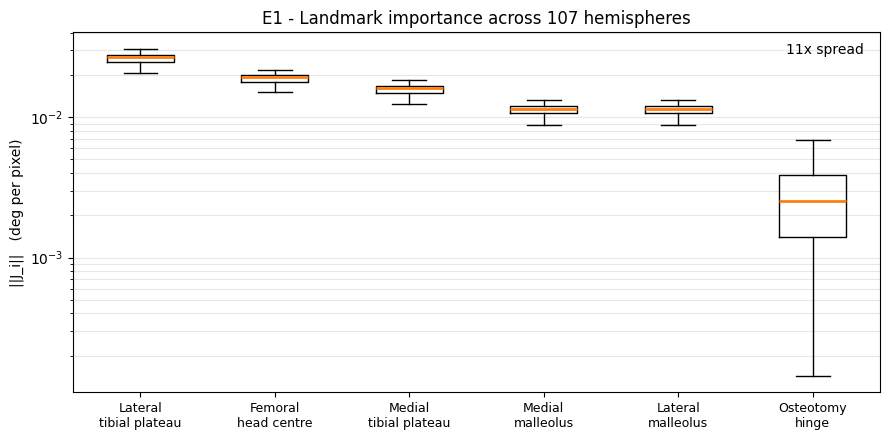

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot([wide[n].values for n in keys], showfliers=False, medianprops=dict(linewidth=2))
ax.set_yscale("log")
ax.set_xticks(range(1, len(keys) + 1))
ax.set_xticklabels([PRETTY[n].replace(" ", "\n", 1) for n in keys], fontsize=9)
ax.set_ylabel("||J_i||   (deg per pixel)")
ax.set_title(f"E1 - Landmark importance across {len(hemispheres)} hemispheres")
ax.grid(axis="y", alpha=0.3, which="both")
ax.annotate(f"{wide[keys[0]].median() / wide[keys[-1]].median():.0f}x spread",
            xy=(0.98, 0.94), xycoords="axes fraction", ha="right", fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / "E1_fig1_importance.png", dpi=200)
plt.show()

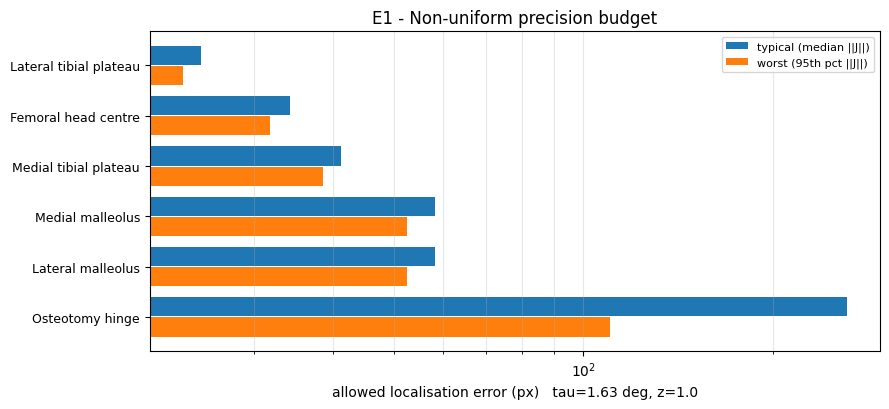

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
b = budget.loc[[PRETTY[n] for n in keys]]
y = np.arange(len(keys))
ax.barh(y - 0.2, b["budget_px (typical)"], height=0.38, label="typical (median ||J||)")
ax.barh(y + 0.2, b["budget_px (worst)"],  height=0.38, label="worst (95th pct ||J||)")
ax.set_yticks(y); ax.set_yticklabels([PRETTY[n] for n in keys], fontsize=9)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel(f"allowed localisation error (px)   tau={TOLERANCE_DEG} deg, z={Z_BUDGET}")
ax.set_title("E1 - Non-uniform precision budget")
ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "E1_fig2_budget.png", dpi=200)
plt.show()

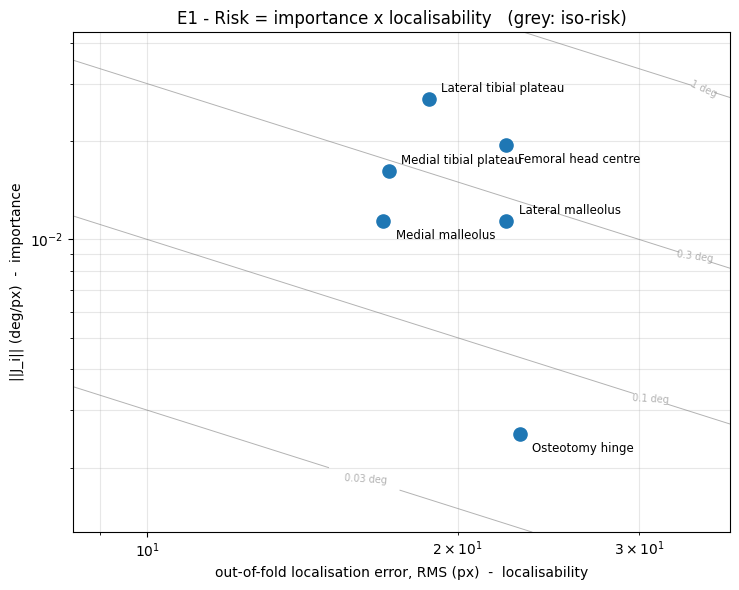

In [10]:
# Risk plane: importance vs localisability, with iso-risk contours.
fig, ax = plt.subplots(figsize=(7.5, 6))
xs = risk_tbl.loc[keys, "loc_err_rms"].values
ys = risk_tbl.loc[keys, "J_median"].values

gx = np.linspace(max(xs.min() * 0.5, 1e-3), xs.max() * 1.6, 200)
gy = np.linspace(ys.min() * 0.5, ys.max() * 1.6, 200)
GX, GY = np.meshgrid(gx, gy)
cs = ax.contour(GX, GY, GX * GY, levels=[0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
                colors="grey", linewidths=0.7, alpha=0.6)
ax.clabel(cs, fmt=lambda v: f"{v:g} deg", fontsize=7)

ax.scatter(xs, ys, s=90, zorder=3)
for j, (n, x, yv) in enumerate(zip(keys, xs, ys)):
    # alternate the label offset: the two malleoli sit almost on top of each other
    ax.annotate(PRETTY[n], (x, yv), textcoords="offset points",
                xytext=(9, 5) if j % 2 == 0 else (9, -13), fontsize=8.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("out-of-fold localisation error, RMS (px)  -  localisability")
ax.set_ylabel("||J_i|| (deg/px)  -  importance")
ax.set_title("E1 - Risk = importance x localisability   (grey: iso-risk)")
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "E1_fig3_risk_plane.png", dpi=200)
plt.show()

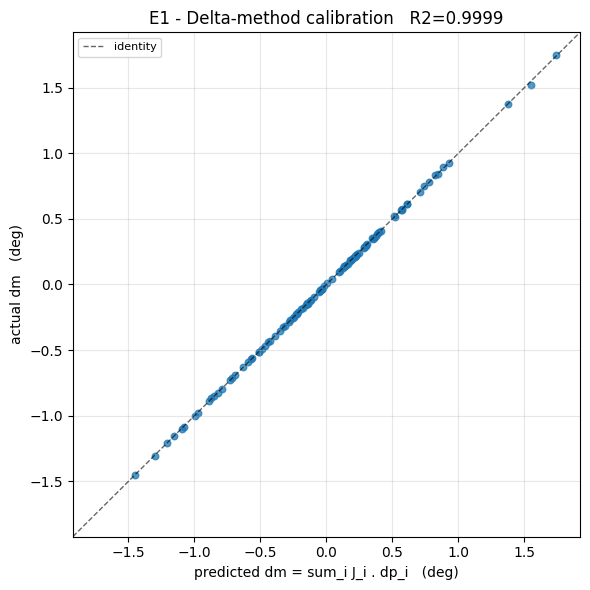

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
lim = float(np.abs(np.r_[cal.actual_dm, cal.pred_dm]).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, alpha=0.6, label="identity")
ax.scatter(cal.pred_dm, cal.actual_dm, s=22, alpha=0.75)
ax.set_xlabel("predicted dm = sum_i J_i . dp_i   (deg)")
ax.set_ylabel("actual dm   (deg)")
ax.set_title(f"E1 - Delta-method calibration   R2={r2:.4f}")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "E1_fig4_calibration.png", dpi=200)
plt.show()

## 8 · Export the sensitivity object $J$

`E1_jacobians.npz` is the artefact Papers B and D consume: the per-hemisphere Jacobian in
`SIDE_KEYS` row order, aligned with `case_id` / `side`, plus the correction angles.

In [12]:
np.savez_compressed(
    OUT_DIR / "E1_jacobians.npz",
    J=J_all,                                                # (n_hemi, 6, 2) deg/px
    landmarks=np.array(SIDE_KEYS),
    case_id=np.array([h["case_id"] for h in hemispheres]),
    side=np.array([h["side"] for h in hemispheres]),
    alpha_deg=alphas,
    tolerance_deg=TOLERANCE_DEG,
    target_size=TARGET_SIZE,
    seed=SEED,
)
jac.to_csv(OUT_DIR / "E1_jacobians_long.csv", index=False)
summary.to_csv(OUT_DIR / "E1_importance_summary.csv")
budget.to_csv(OUT_DIR / "E1_precision_budget.csv")
risk_tbl.to_csv(OUT_DIR / "E1_risk_budget.csv")
cal.to_csv(OUT_DIR / "E1_calibration.csv", index=False)

manifest = {
    "experiment": "Paper A / E1 - landmark importance and precision budget",
    "annotations": COCO_JSON_PATH,
    "predictions": pred_note,
    "n_hemispheres": len(hemispheres),
    "n_radiographs": n_rad,
    "seed": SEED, "target_size": TARGET_SIZE, "heatmap_scale": HEATMAP_SCALE,
    "tolerance_deg": TOLERANCE_DEG, "z_budget": Z_BUDGET,
    "side_keys": SIDE_KEYS,
    "pixel_spacing_mm": (float(np.mean(spacings)) if spacings else None),
    "alpha_deg": {"mean": float(alphas.mean()), "median": float(np.median(alphas)),
                  "min": float(alphas.min()), "max": float(alphas.max())},
    "importance_median_deg_per_px": {n: float(wide[n].median()) for n in SIDE_KEYS},
    "importance_ratio_vs_least": {n: float(ratios[n].median()) for n in SIDE_KEYS},
    "least_influential": least,
    "budget_px_typical": dict(zip(SIDE_KEYS,
                                  precision_budget(wide.reindex(columns=SIDE_KEYS).median().values,
                                                   tolerance_deg=TOLERANCE_DEG,
                                                   z=Z_BUDGET, k=K).tolist())),
    "risk_mean_deg": {n: float(risk_tbl.loc[n, "risk_mean"]) for n in SIDE_KEYS},
    "angle_error_deg": {"mean": float(cal.abs_err_deg.abs().mean()),
                        "median": float(cal.abs_err_deg.abs().median()),
                        "max": float(cal.abs_err_deg.abs().max()),
                        "within_tolerance": float((cal.abs_err_deg.abs() <= TOLERANCE_DEG).mean())},
    "delta_method_r2": float(r2),
    "delta_method_mae_deg": float(mae),
    "verification": checks,
    "torch": torch.__version__,
}
(OUT_DIR / "E1_manifest.json").write_text(json.dumps(manifest, indent=2))

print(f"written to {OUT_DIR.resolve()}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:34s} {f.stat().st_size/1024:8.1f} KB")

written to /tf/notebooks/results/E1
  E1_calibration.csv                      9.3 KB
  E1_cohort.npz                          15.3 KB
  E1_fig1_importance.png                 56.3 KB
  E1_fig2_budget.png                     67.8 KB
  E1_fig3_risk_plane.png                139.5 KB
  E1_fig4_calibration.png                93.3 KB
  E1_importance_summary.csv               1.1 KB
  E1_jacobians.npz                       10.9 KB
  E1_jacobians_long.csv                  91.8 KB
  E1_manifest.json                        2.3 KB
  E1_precision_budget.csv                 0.6 KB
  E1_risk_budget.csv                      0.8 KB


## 9 · Result

In [13]:
bar = "=" * 72
lines = [bar, "E1 - RESULT", bar,
         f"Cohort             {len(hemispheres)} hemispheres, {n_rad} radiographs",
         f"Correction angle   mean {alphas.mean():.2f} deg, "
         f"range {alphas.min():.2f}-{alphas.max():.2f} deg",
         f"Predictions        {pred_note}",
         "",
         f"{'Landmark':26s}{'||J|| (deg/px)':>16s}{'ratio':>9s}{'budget (px)':>14s}"]
for n in keys:
    lines.append(f"  {PRETTY[n]:24s}{wide[n].median():16.5f}{ratios[n].median():8.1f}x"
                 f"{TOLERANCE_DEG / (Z_BUDGET * math.sqrt(K) * wide[n].median()):14.2f}")
lines += ["",
          f"Spread             {wide[keys[0]].median() / wide[keys[-1]].median():.0f}x between "
          f"{PRETTY[keys[0]].lower()} and {PRETTY[keys[-1]].lower()}",
          f"Highest risk       {PRETTY[risk_tbl.index[0]]} "
          f"({risk_tbl['risk_share_%'].iloc[0]:.0f}% of total predicted angle error)",
          f"Angle error        mean {cal.abs_err_deg.abs().mean():.3f} deg, "
          f"max {cal.abs_err_deg.abs().max():.3f} deg, "
          f"{100 * (cal.abs_err_deg.abs() <= TOLERANCE_DEG).mean():.1f}% within tolerance",
          f"Delta-method       R2 = {r2:.4f}, MAE {mae:.4f} deg "
          f"-> linearisation adequate at the observed error scale",
          bar]
print("\n".join(lines))

E1 - RESULT
Cohort             107 hemispheres, 54 radiographs
Correction angle   mean 6.92 deg, range 0.46-24.82 deg
Predictions        out-of-fold U-Net, best_model_fold[1-5].pt

Landmark                    ||J|| (deg/px)    ratio   budget (px)
  Lateral tibial plateau           0.02693    10.0x         24.71
  Femoral head centre              0.01943     7.1x         34.24
  Medial tibial plateau            0.01616     6.0x         41.18
  Medial malleolus                 0.01142     4.4x         58.25
  Lateral malleolus                0.01142     4.4x         58.25
  Osteotomy hinge                  0.00254     1.0x        262.06

Spread             11x between lateral tibial plateau and osteotomy hinge
Highest risk       Lateral tibial plateau (29% of total predicted angle error)
Angle error        mean 0.452 deg, max 1.746 deg, 99.1% within tolerance
Delta-method       R2 = 0.9999, MAE 0.0026 deg -> linearisation adequate at the observed error scale
